# Perbandingan Metode K-Means dan Hierarchical Clustering dalam Pengelompokan Kabupaten/Kota di Jawa Tengah Berdasarkan Indikator Kesenjangan Digital

# Tujuan Bisnis :

Project ini bertujuan untuk mengelompokkan 35 kabupaten/kota di Provinsi Jawa Tengah
berdasarkan empat indikator kesenjangan digital tahun 2020, yaitu:
1. Persentase penduduk menggunakan HP
2. Persentase penduduk mengakses internet
3. Persentase desa/kelurahan dengan penerimaan sinyal internet 4G
4. Persentase rumah tangga yang memiliki komputer/laptop

Data yang digunakan merupakan data sekunder dari Badan Pusat Statistik (BPS)
Provinsi Jawa Tengah tahun 2020. Proses analisis meliputi validasi dan standardisasi
data (Z-score) sebelum dilakukan clustering.

Dua metode clustering yang diterapkan dan dibandingkan adalah:
- K-Means Clustering, dengan penentuan jumlah cluster menggunakan Elbow Method
  dan Silhouette Method
- Hierarchical Clustering (agglomerative) dengan Ward linkage

Hasil pengelompokan kedua metode dievaluasi dan dibandingkan menggunakan Silhouette Score dan Adjusted Rand Index (ARI), untuk mengetahui kualitas serta tingkat kesesuaian antar hasil clustering. Interpretasi cluster dilakukan berdasarkan pola rata-rata nilai indikator pada masing-masing kelompok, yang kemudian diurutkan dan diberi label tingkat akses dan pemanfaatan TIK (Rendah, Sedang, Tinggi, Sangat Tinggi) berdasarkan skor rata-rata terstandardisasi, tanpa memberikan penilaian kualitatif (baik/buruk) terhadap wilayah tertentu.

# 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

from scipy.cluster.hierarchy import dendrogram, linkage

# 2. Membaca Data Excel

In [ ]:
df = pd.read_excel("/content/data_gabungan cluster.xlsx")
df.head()

,Kabupaten_Kota,Persentase_HP_Laki_laki_Perempuan,Persentase_Internet_Laki_laki_Perempuan,Persentase Desa/Kelurahandan Penerimaan Sinyal Internet Telepon Seluler 4G,Persentase Rumah Tangga yang Memiliki Komputer/Laptop
0,3300 PROVINSI JAWA TENGAH,75.82,54.72,158.56,16.02
1,3301 Kabupaten Cilacap,77.12,52.07,5.18,12.20
2,3302 Kabupaten Banyumas,81.18,57.60,6.31,17.00
3,3303 Kabupaten Purbalingga,74.53,48.54,4.50,12.04
4,3304 Kabupaten Banjarnegara,72.77,47.48,5.09,10.56


# 3. Melihat Struktur Data

In [ ]:
print("Jumlah baris dan kolom:", df.shape)
print("\nNama kolom:")
print(df.columns.tolist())

Jumlah baris dan kolom: (36, 5)

Nama kolom:
['Kabupaten_Kota', 'Persentase_HP_Laki_laki_Perempuan', 'Persentase_Internet_Laki_laki_Perempuan', 'Persentase Desa/Kelurahandan Penerimaan Sinyal Internet Telepon Seluler 4G', 'Persentase Rumah Tangga yang Memiliki Komputer/Laptop']


# 4. Menghapus baris Provinsi Jawa Tengah

In [ ]:
df = df[df["Kabupaten_Kota"] != "3300 PROVINSI JAWA TENGAH"].copy()
print("Jumlah kabupaten/kota:", len(df))

Jumlah kabupaten/kota: 35


# 5. Melihat daftar kabupaten/kota


In [ ]:
print(df["Kabupaten_Kota"].tolist())

['3301 Kabupaten Cilacap', '3302 Kabupaten Banyumas', '3303 Kabupaten Purbalingga', '3304 Kabupaten Banjarnegara', '3305 Kabupaten Kebumen', '3306 Kabupaten Purworejo', '3307 Kabupaten Wonosobo', '3308 Kabupaten Magelang', '3309 Kabupaten Boyolali', '3310 Kabupaten Klaten', '3311 Kabupaten Sukoharjo', '3312 Kabupaten Wonogiri', '3313 Kabupaten Karanganyar', '3314 Kabupaten Sragen', '3315 Kabupaten Grobogan', '3316 Kabupaten Blora', '3317 Kabupaten Rembang', '3318 Kabupaten Pati', '3319 Kabupaten Kudus', '3320 Kabupaten Jepara', '3321 Kabupaten Demak', '3322 Kabupaten Semarang', '3323 Kabupaten Temanggung', '3324 Kabupaten Kendal', '3325 Kabupaten Batang', '3326 Kabupaten Pekalongan', '3327 Kabupaten Pemalang', '3328 Kabupaten Tegal', '3329 Kabupaten Brebes', '3371 Kota Magelang', '3372 Kota Surakarta', '3373 Kota Salatiga', '3374 Kota Semarang', '3375 Kota Pekalongan', '3376 Kota Tegal']


# 6. Mengecek missing value

In [ ]:
print(df.isnull().sum())

Kabupaten_Kota                                                                0
Persentase_HP_Laki_laki_Perempuan                                             0
Persentase_Internet_Laki_laki_Perempuan                                       0
Persentase Desa/Kelurahandan Penerimaan Sinyal Internet Telepon Seluler 4G    0
Persentase Rumah Tangga yang Memiliki Komputer/Laptop                         0
dtype: int64


# 7. Mengecek data duplikat

In [ ]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


# 8. Menentukan variabel yang digunakan untuk clustering


In [ ]:
features = [
    "Persentase_HP_Laki_laki_Perempuan",
    "Persentase_Internet_Laki_laki_Perempuan",
    "Persentase Desa/Kelurahandan Penerimaan Sinyal Internet Telepon Seluler 4G",
    "Persentase Rumah Tangga yang Memiliki Komputer/Laptop"
]

X = df[features].copy()

X.head()

,Persentase_HP_Laki_laki_Perempuan,Persentase_Internet_Laki_laki_Perempuan,Persentase Desa/Kelurahandan Penerimaan Sinyal Internet Telepon Seluler 4G,Persentase Rumah Tangga yang Memiliki Komputer/Laptop
1,77.12,52.07,5.18,12.20
2,81.18,57.60,6.31,17.00
3,74.53,48.54,4.50,12.04
4,72.77,47.48,5.09,10.56
5,81.61,52.55,8.31,14.32


# 9. Statistik deskriptif variabel clustering


In [ ]:
X.describe()

,Persentase_HP_Laki_laki_Perempuan,Persentase_Internet_Laki_laki_Perempuan,Persentase Desa/Kelurahandan Penerimaan Sinyal Internet Telepon Seluler 4G,Persentase Rumah Tangga yang Memiliki Komputer/Laptop
count,35.000000,35.000000,35.000000,35.000000
mean,76.370286,55.940286,4.530286,17.210000
std,5.195991,8.911930,2.110614,8.545621
min,68.930000,46.360000,0.340000,6.420000
25%,72.700000,49.515000,3.535000,11.680000
50%,75.570000,52.510000,4.860000,15.130000
75%,78.890000,59.465000,5.515000,18.715000
max,87.030000,76.240000,8.480000,43.450000


Dari 35 kabupaten/kota, rata - rata persentase penduduk yang menggunakan HP adalah 76,37% (rentang 68,93% - 87,03%), dan rata - rata akses internet 55,94% (rentang 46,36% - 76,24%) — kedua variabel ini relatif merata antarwilayah (standar deviasi rendah, masing-masing 5,20 dan 8,91). Sebaliknya, variabel penerimaan sinyal 4G desa/kelurahan (rata-rata 4,53%, rentang 0,34% - 8,48%) dan kepemilikan komputer/laptop (rata-rata 17,21%, rentang 6,42% - 43,45%) menunjukkan variasi jauh lebih besar antarwilayah

# 10. Standardisasi data

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features,
    index=df.index
)

X_scaled.head()

,Persentase_HP_Laki_laki_Perempuan,Persentase_Internet_Laki_laki_Perempuan,Persentase Desa/Kelurahandan Penerimaan Sinyal Internet Telepon Seluler 4G,Persentase Rumah Tangga yang Memiliki Komputer/Laptop
1,0.146394,-0.440622,0.312326,-0.594824
2,0.939173,0.188954,0.855532,-0.024933
3,-0.359345,-0.842503,-0.014559,-0.613821
4,-0.703013,-0.963181,0.269062,-0.789537
5,1.023137,-0.385975,1.816957,-0.343122


Standardisasi dilakukan menggunakan Z-score agar keempat variabel memiliki skala yang sebanding sebelum clustering. Setelah standardisasi, rata-rata seluruh variabel mendekati 0 dan standar deviasi sekitar 1,01, sehingga tidak ada variabel yang mendominasi clustering hanya karena memiliki skala yang lebih besar

# 11. Mengecek rata-rata dan standar deviasi setelah standardisasi

In [ ]:
print("Rata-rata:")
print(X_scaled.mean())

print("\nStandar deviasi:")
print(X_scaled.std())

Rata-rata:
Persentase_HP_Laki_laki_Perempuan                                            -1.459150e-16
Persentase_Internet_Laki_laki_Perempuan                                       5.709718e-17
Persentase Desa/Kelurahandan Penerimaan Sinyal Internet Telepon Seluler 4G    4.948423e-16
Persentase Rumah Tangga yang Memiliki Komputer/Laptop                        -7.771561e-17
dtype: float64

Standar deviasi:
Persentase_HP_Laki_laki_Perempuan                                             1.014599
Persentase_Internet_Laki_laki_Perempuan                                       1.014599
Persentase Desa/Kelurahandan Penerimaan Sinyal Internet Telepon Seluler 4G    1.014599
Persentase Rumah Tangga yang Memiliki Komputer/Laptop                         1.014599
dtype: float64


# 12. Elbow Method


In [ ]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 13. Membuat grafik Elbow

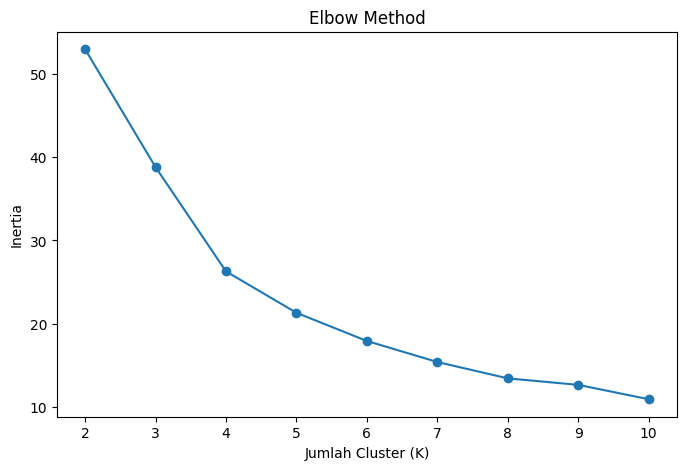

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

Nilai inertia menurun dari sekitar 53 pada K=2 menjadi sekitar 26 pada K=4, kemudian penurunannya semakin melandai hingga sekitar 11 pada K=10. Pola tersebut menunjukkan titik siku berada sekitar K=3–4, sehingga jumlah cluster 3 atau 4 dapat dipertimbangkan dalam analisis

# 14. Silhouette Score


In [ ]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

silhouette_table = pd.DataFrame({
    "Jumlah Cluster": range(2, 11),
    "Silhouette Score": silhouette_scores
})

silhouette_table

,Jumlah Cluster,Silhouette Score
0,2,0.572319
1,3,0.458135
2,4,0.410198
3,5,0.330712
4,6,0.330912
5,7,0.302059
6,8,0.304215
7,9,0.256358
8,10,0.259395


# 15. Grafik Silhouette Score

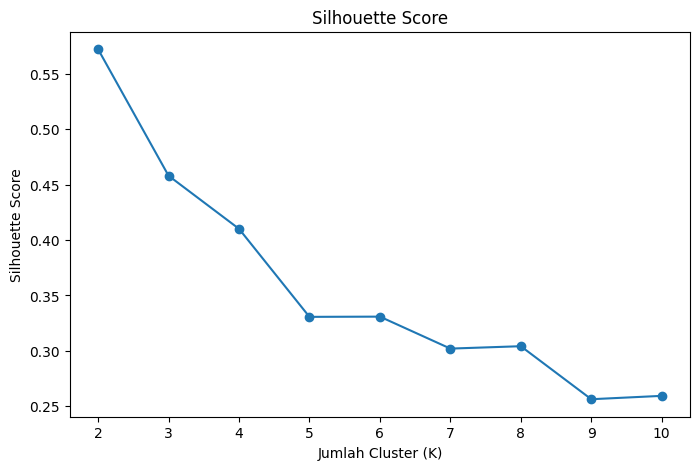

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

Hasil pengujian menunjukkan nilai Silhouette Score sebesar 0,5723 untuk 2 cluster, 0,4581 untuk 3 cluster, 0,4102 untuk 4 cluster, dan terus menurun pada jumlah cluster yang lebih besar. Meskipun nilai tertinggi terdapat pada K=2, analisis selanjutnya menggunakan 4 cluster agar pengelompokan dapat menggambarkan empat tingkat TIK, yaitu Rendah, Sedang, Tinggi, dan Sangat Tinggi

# Alasan Pemilihan k=4

Berdasarkan Elbow Method, penurunan inertia mulai melandai setelah K=4. Sementara itu, Silhouette Score menunjukkan bahwa K=2 memiliki nilai tertinggi. Namun, K=4 dipilih karena memberikan granularitas pengelompokan yang lebih terperinci dan memungkinkan karakteristik kabupaten/kota dibedakan menjadi gradasi tingkat akses dan pemanfaatan TIK, yaitu rendah, sedang, tinggi, dan sangat tinggi. Dengan demikian, K=4 digunakan untuk proses clustering selanjutnya

# 16. K-Means dengan 4 cluster


In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster_KMeans_Asli"] = kmeans.fit_predict(X_scaled) + 1

df[["Kabupaten_Kota", "Cluster_KMeans_Asli"]]

,Kabupaten_Kota,Cluster_KMeans_Asli
1,3301 Kabupaten Cilacap,2
2,3302 Kabupaten Banyumas,4
3,3303 Kabupaten Purbalingga,2
4,3304 Kabupaten Banjarnegara,2
5,3305 Kabupaten Kebumen,4
6,3306 Kabupaten Purworejo,4
7,3307 Kabupaten Wonosobo,2
8,3308 Kabupaten Magelang,2
9,3309 Kabupaten Boyolali,2
10,3310 Kabupaten Klaten,4


# 17. Jumlah anggota setiap cluster K-Means


In [ ]:
print(
    df["Cluster_KMeans_Asli"]
    .value_counts()
    .sort_index()
)

Cluster_KMeans_Asli
1     5
2    20
3     4
4     6
Name: count, dtype: int64


Dari 35 kabupaten/kota, 20 wilayah masuk kategori Rendah, 5 wilayah kategori Sedang, 6 wilayah kategori Tinggi, dan 4 wilayah kategori Sangat Tinggi. Dengan demikian, sebagian besar wilayah dalam hasil K-Means berada pada kategori Rendah, yaitu 20 dari 35 wilayah

# 18. Profil rata-rata K-Means

In [ ]:
profil_kmeans = df.groupby(
    "Cluster_KMeans_Asli"
)[features].mean()

profil_kmeans

,Persentase_HP_Laki_laki_Perempuan,Persentase_Internet_Laki_laki_Perempuan,Persentase Desa/Kelurahandan Penerimaan Sinyal Internet Telepon Seluler 4G,Persentase Rumah Tangga yang Memiliki Komputer/Laptop
Cluster_KMeans_Asli,,,,
1,80.390000,62.8900,2.266000,21.580000
2,72.893500,50.6080,4.909500,12.704500
3,85.877500,75.7825,1.335000,36.920000
4,78.271667,54.6950,7.283333,15.446667


Hasil K-Means menunjukkan bahwa Cluster 1 (Rendah) memiliki rata-rata penggunaan HP 72,89% dan akses internet 50,61%, sedangkan Cluster 2 (Sedang) memiliki penggunaan HP 80,39% dan akses internet 62,89%. Cluster 3 (Tinggi) memiliki penggunaan HP 78,27% dan akses internet 54,70%, sementara Cluster 4 (Sangat Tinggi) memiliki nilai tertinggi untuk penggunaan HP 85,88% dan akses internet 75,78%

# 19. Menghitung rata-rata skor standar setiap cluster

In [ ]:
temp_kmeans = X_scaled.copy()

temp_kmeans["Cluster"] = df["Cluster_KMeans_Asli"].values

skor_cluster_kmeans = (
    temp_kmeans
    .groupby("Cluster")
    .mean()
    .mean(axis=1)
    .sort_values()
)

skor_cluster_kmeans

,0
Cluster,
2,-0.409649
1,0.251622
4,0.335893
3,1.229880


# 20. Membuat urutan cluster dari rendah ke tinggi


In [ ]:
urutan_kmeans = skor_cluster_kmeans.index.tolist()

mapping_kmeans = {
    cluster_asli: cluster_baru
    for cluster_baru, cluster_asli
    in enumerate(urutan_kmeans, start=1)
}

mapping_kmeans

{2: 1, 1: 2, 4: 3, 3: 4}

# 21. Mengubah nomor cluster menjadi urutan tingkat TIK


In [ ]:
df["Cluster_KMeans"] = (
    df["Cluster_KMeans_Asli"]
    .map(mapping_kmeans)
)

df[[
    "Kabupaten_Kota",
    "Cluster_KMeans_Asli",
    "Cluster_KMeans"
]]

,Kabupaten_Kota,Cluster_KMeans_Asli,Cluster_KMeans
1,3301 Kabupaten Cilacap,2,1
2,3302 Kabupaten Banyumas,4,3
3,3303 Kabupaten Purbalingga,2,1
4,3304 Kabupaten Banjarnegara,2,1
5,3305 Kabupaten Kebumen,4,3
6,3306 Kabupaten Purworejo,4,3
7,3307 Kabupaten Wonosobo,2,1
8,3308 Kabupaten Magelang,2,1
9,3309 Kabupaten Boyolali,2,1
10,3310 Kabupaten Klaten,4,3


# 22. Memberikan label tingkat akses dan pemanfaatan TIK


In [ ]:
label_cluster = {
    1: "Rendah",
    2: "Sedang",
    3: "Tinggi",
    4: "Sangat Tinggi"
}

df["Tingkat_TIK_KMeans"] = (
    df["Cluster_KMeans"]
    .map(label_cluster)
)

df[[
    "Kabupaten_Kota",
    "Cluster_KMeans",
    "Tingkat_TIK_KMeans"
]]

,Kabupaten_Kota,Cluster_KMeans,Tingkat_TIK_KMeans
1,3301 Kabupaten Cilacap,1,Rendah
2,3302 Kabupaten Banyumas,3,Tinggi
3,3303 Kabupaten Purbalingga,1,Rendah
4,3304 Kabupaten Banjarnegara,1,Rendah
5,3305 Kabupaten Kebumen,3,Tinggi
6,3306 Kabupaten Purworejo,3,Tinggi
7,3307 Kabupaten Wonosobo,1,Rendah
8,3308 Kabupaten Magelang,1,Rendah
9,3309 Kabupaten Boyolali,1,Rendah
10,3310 Kabupaten Klaten,3,Tinggi


# 23. Profil akhir K-Means berdasarkan label


In [ ]:
profil_akhir_kmeans = df.groupby(
    ["Cluster_KMeans", "Tingkat_TIK_KMeans"]
)[features].mean()

profil_akhir_kmeans.round(2)

,,Persentase_HP_Laki_laki_Perempuan,Persentase_Internet_Laki_laki_Perempuan,Persentase Desa/Kelurahandan Penerimaan Sinyal Internet Telepon Seluler 4G,Persentase Rumah Tangga yang Memiliki Komputer/Laptop
Cluster_KMeans,Tingkat_TIK_KMeans,,,,
1,Rendah,72.89,50.61,4.91,12.70
2,Sedang,80.39,62.89,2.27,21.58
3,Tinggi,78.27,54.70,7.28,15.45
4,Sangat Tinggi,85.88,75.78,1.34,36.92


# 24. Jumlah wilayah setiap cluster


In [ ]:
df["Tingkat_TIK_KMeans"].value_counts()

,count
Tingkat_TIK_KMeans,
Rendah,20
Tinggi,6
Sedang,5
Sangat Tinggi,4


# 25. Membuat linkage untuk Hierarchical Clustering



In [ ]:
Z = linkage(
    X_scaled,
    method="ward"
)

# 26. Membuat dendrogram

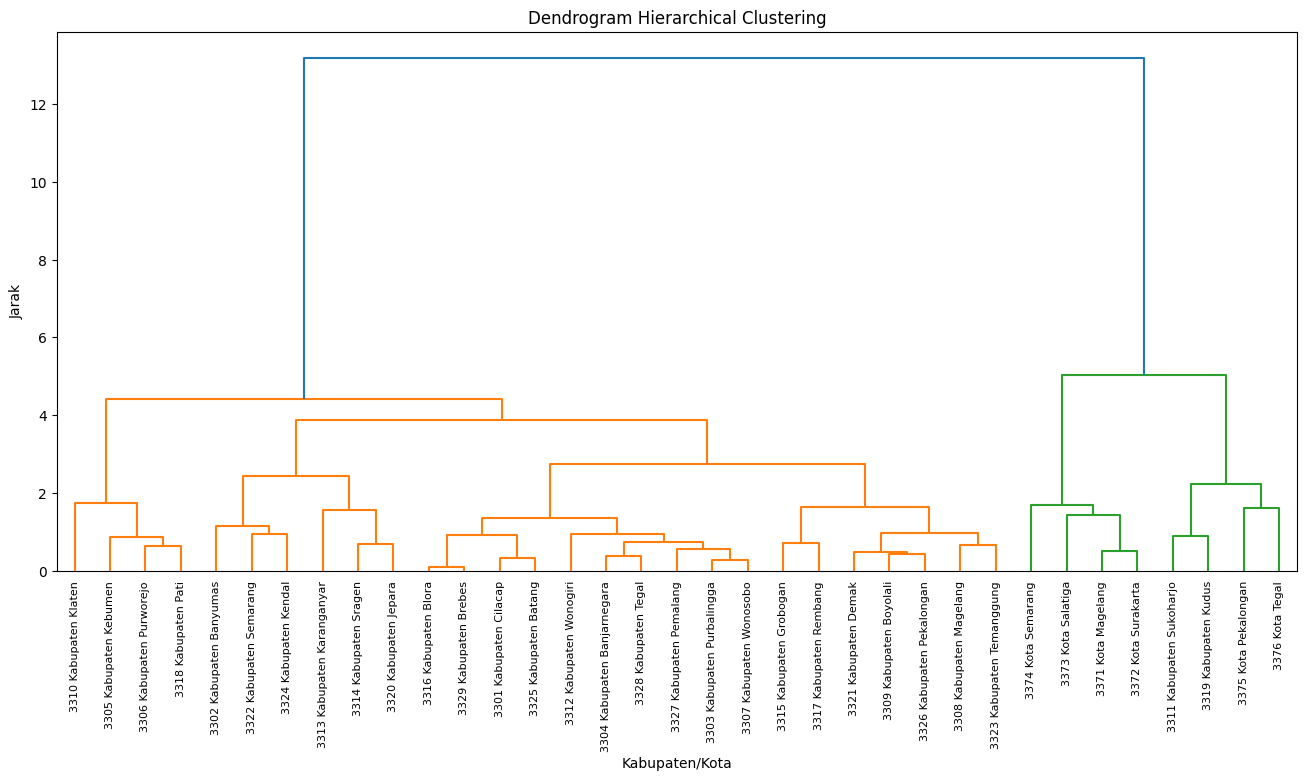

In [ ]:
plt.figure(figsize=(16, 7))

dendrogram(
    Z,
    labels=df["Kabupaten_Kota"].values,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Dendrogram Hierarchical Clustering")
plt.xlabel("Kabupaten/Kota")
plt.ylabel("Jarak")
plt.show()

# 27. Hierarchical Clustering dengan 4 cluster


In [ ]:
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

df["Cluster_Hierarchical_Asli"] = (
    hierarchical.fit_predict(X_scaled) + 1
)

df[[
    "Kabupaten_Kota",
    "Cluster_Hierarchical_Asli"
]]

,Kabupaten_Kota,Cluster_Hierarchical_Asli
1,3301 Kabupaten Cilacap,1
2,3302 Kabupaten Banyumas,1
3,3303 Kabupaten Purbalingga,1
4,3304 Kabupaten Banjarnegara,1
5,3305 Kabupaten Kebumen,4
6,3306 Kabupaten Purworejo,4
7,3307 Kabupaten Wonosobo,1
8,3308 Kabupaten Magelang,1
9,3309 Kabupaten Boyolali,1
10,3310 Kabupaten Klaten,4


Hierarchical Clustering dilakukan menggunakan metode agglomerative dengan 4 cluster dan pendekatan Ward linkage. Hasilnya menghasilkan pengelompokan wilayah berdasarkan kemiripan karakteristik empat indikator kesenjangan digital yang telah distandarisasi

# 28. Profil rata-rata Hierarchical

In [ ]:
profil_hierarchical = df.groupby(
    "Cluster_Hierarchical_Asli"
)[features].mean()

profil_hierarchical.round(2)

,Persentase_HP_Laki_laki_Perempuan,Persentase_Internet_Laki_laki_Perempuan,Persentase Desa/Kelurahandan Penerimaan Sinyal Internet Telepon Seluler 4G,Persentase Rumah Tangga yang Memiliki Komputer/Laptop
Cluster_Hierarchical_Asli,,,,
1,73.68,51.71,4.97,13.37
2,80.84,63.17,1.71,21.72
3,85.88,75.78,1.34,36.92
4,77.88,53.18,8.01,15.04


Rata-rata penggunaan HP pada cluster Hierarchical adalah 73,68%, 80,84%, 85,88%, dan 77,88%, sedangkan rata-rata akses internet masing-masing sebesar 51,71%, 63,17%, 75,78%, dan 53,18%. Hasil ini menunjukkan adanya perbedaan karakteristik indikator digital antarcluster yang kemudian digunakan untuk memberikan label tingkat TIK

# 29. Menghitung skor relatif Hierarchical


In [ ]:
temp_hierarchical = X_scaled.copy()

temp_hierarchical["Cluster"] = (
    df["Cluster_Hierarchical_Asli"].values
)

skor_cluster_hierarchical = (
    temp_hierarchical
    .groupby("Cluster")
    .mean()
    .mean(axis=1)
    .sort_values()
)

skor_cluster_hierarchical

,0
Cluster,
1,-0.312687
2,0.219068
4,0.349001
3,1.229880


# 30. Membuat mapping cluster Hierarchical


In [ ]:
urutan_hierarchical = (
    skor_cluster_hierarchical.index.tolist()
)

mapping_hierarchical = {
    cluster_asli: cluster_baru
    for cluster_baru, cluster_asli
    in enumerate(urutan_hierarchical, start=1)
}

mapping_hierarchical

{1: 1, 2: 2, 4: 3, 3: 4}

Nomor cluster asli dari metode Hierarchical disesuaikan melalui mapping {1:1, 2:2, 4:3, 3:4}. Pengubahan ini dilakukan agar nomor cluster mengikuti urutan tingkat TIK dari Rendah, Sedang, Tinggi, hingga Sangat Tinggi, sehingga lebih mudah dibandingkan dengan hasil K-Means.

# 31. Mengubah nomor cluster Hierarchical


In [ ]:
df["Cluster_Hierarchical"] = (
    df["Cluster_Hierarchical_Asli"]
    .map(mapping_hierarchical)
)

df["Tingkat_TIK_Hierarchical"] = (
    df["Cluster_Hierarchical"]
    .map(label_cluster)
)

# 32. Profil akhir Hierarchical


In [ ]:
profil_akhir_hierarchical = df.groupby(
    ["Cluster_Hierarchical", "Tingkat_TIK_Hierarchical"]
)[features].mean()

profil_akhir_hierarchical.round(2)

,,Persentase_HP_Laki_laki_Perempuan,Persentase_Internet_Laki_laki_Perempuan,Persentase Desa/Kelurahandan Penerimaan Sinyal Internet Telepon Seluler 4G,Persentase Rumah Tangga yang Memiliki Komputer/Laptop
Cluster_Hierarchical,Tingkat_TIK_Hierarchical,,,,
1,Rendah,73.68,51.71,4.97,13.37
2,Sedang,80.84,63.17,1.71,21.72
3,Tinggi,77.88,53.18,8.01,15.04
4,Sangat Tinggi,85.88,75.78,1.34,36.92


# 33. Silhouette Score K-Means


In [ ]:
sil_kmeans = silhouette_score(
    X_scaled,
    df["Cluster_KMeans_Asli"]
)

print("Silhouette Score K-Means:", round(sil_kmeans, 4))

Silhouette Score K-Means: 0.4102


# 34. Silhouette Score Hierarchical


In [ ]:
sil_hierarchical = silhouette_score(
    X_scaled,
    df["Cluster_Hierarchical_Asli"]
)

print(
    "Silhouette Score Hierarchical:",
    round(sil_hierarchical, 4)
)

Silhouette Score Hierarchical: 0.3738


# 35. Tabel perbandingan Silhouette Score


In [ ]:
perbandingan_silhouette = pd.DataFrame({
    "Metode": [
        "K-Means",
        "Hierarchical"
    ],
    "Silhouette Score": [
        sil_kmeans,
        sil_hierarchical
    ]
})

perbandingan_silhouette

,Metode,Silhouette Score
0,K-Means,0.410198
1,Hierarchical,0.373834


Silhouette Score K-Means sebesar 0,4102, sedangkan Hierarchical sebesar 0,3738. Kedua metode menghasilkan nilai positif, tetapi nilai K-Means lebih tinggi sehingga berdasarkan ukuran Silhouette Score, struktur cluster K-Means lebih terpisah dibandingkan hasil Hierarchical pada 4 cluster

# 36. Menghitung Adjusted Rand Index


In [ ]:
ari = adjusted_rand_score(
    df["Cluster_KMeans_Asli"],
    df["Cluster_Hierarchical_Asli"]
)

print("Adjusted Rand Index:", round(ari, 4))

Adjusted Rand Index: 0.7454


Nilai Adjusted Rand Index antara hasil K-Means dan Hierarchical adalah 0,7454. Nilai tersebut menunjukkan bahwa kedua metode menghasilkan pengelompokan wilayah yang cukup sesuai satu sama lain, meskipun masih terdapat beberapa perbedaan penempatan kabupaten/kota antarcluster.

# 37. Membandingkan hasil clustering setiap wilayah


In [ ]:
hasil_perbandingan = df[[
    "Kabupaten_Kota",
    "Cluster_KMeans",
    "Tingkat_TIK_KMeans",
    "Cluster_Hierarchical",
    "Tingkat_TIK_Hierarchical"
]].copy()

hasil_perbandingan

,Kabupaten_Kota,Cluster_KMeans,Tingkat_TIK_KMeans,Cluster_Hierarchical,Tingkat_TIK_Hierarchical
1,3301 Kabupaten Cilacap,1,Rendah,1,Rendah
2,3302 Kabupaten Banyumas,3,Tinggi,1,Rendah
3,3303 Kabupaten Purbalingga,1,Rendah,1,Rendah
4,3304 Kabupaten Banjarnegara,1,Rendah,1,Rendah
5,3305 Kabupaten Kebumen,3,Tinggi,3,Tinggi
6,3306 Kabupaten Purworejo,3,Tinggi,3,Tinggi
7,3307 Kabupaten Wonosobo,1,Rendah,1,Rendah
8,3308 Kabupaten Magelang,1,Rendah,1,Rendah
9,3309 Kabupaten Boyolali,1,Rendah,1,Rendah
10,3310 Kabupaten Klaten,3,Tinggi,3,Tinggi


# 38. Membaca data GeoJSON Jawa Tengah

In [ ]:
jateng = gpd.read_file(
    "/content/kab_kota.geojson"
)

jateng.head()

,code,name,level,geometry
0,11.05,Kabupaten Aceh Barat,regency,"POLYGON ((96.24327 4.71232, 96.26028 4.71238, ..."
1,11.12,Kabupaten Aceh Barat Daya,regency,"MULTIPOLYGON (((96.82554 3.69729, 96.82493 3.6..."
2,11.06,Kabupaten Aceh Besar,regency,"MULTIPOLYGON (((95.20726 5.27931, 95.20628 5.2..."
3,11.14,Kabupaten Aceh Jaya,regency,"MULTIPOLYGON (((95.58276 4.61059, 95.58191 4.6..."
4,11.01,Kabupaten Aceh Selatan,regency,"MULTIPOLYGON (((97.59379 2.80797, 97.59286 2.8..."


# 39. Membuat nama wilayah tanpa kode 4 digit


In [ ]:
df["Nama_Wilayah"] = (
    df["Kabupaten_Kota"]
    .str.replace(r"^\d{4}\s+", "", regex=True)
    .str.strip()
)

jateng["Nama_Wilayah"] = (
    jateng["name"]
    .str.strip()
)

# 40. Menggabungkan hasil K-Means dengan GeoJSON


In [ ]:
map_data_kmeans = jateng.merge(
    df[
        [
            "Nama_Wilayah",
            "Cluster_KMeans",
            "Tingkat_TIK_KMeans"
        ]
    ],
    on="Nama_Wilayah",
    how="left"
)

# 41. Mengecek hasil penggabungan


In [ ]:
print(
    map_data_kmeans[
        "Cluster_KMeans"
    ].value_counts(dropna=False)
)

Cluster_KMeans
NaN    479
1.0     20
3.0      6
2.0      5
4.0      4
Name: count, dtype: int64


# 42. Peta hasil K-Means


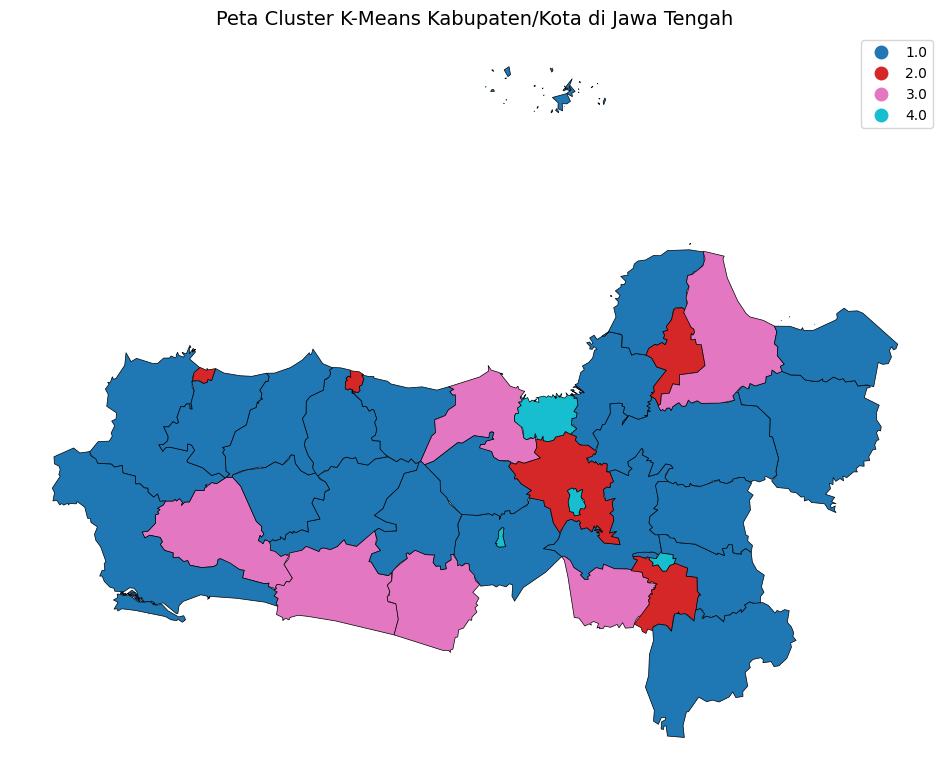

In [ ]:
fig, ax = plt.subplots(
    figsize=(12, 12)
)

map_data_kmeans.plot(
    column="Cluster_KMeans",
    categorical=True,
    legend=True,
    linewidth=0.5,
    edgecolor="black",
    ax=ax
)

ax.set_title(
    "Peta Cluster K-Means Kabupaten/Kota di Jawa Tengah",
    fontsize=14
)

ax.axis("off")

plt.show()

Hasil clustering K-Means kemudian digabungkan dengan data spasial Jawa Tengah untuk memvisualisasikan persebaran cluster. Dari hasil penggabungan, terdapat 20 wilayah Cluster 1, 5 wilayah Cluster 2, 6 wilayah Cluster 3, dan 4 wilayah Cluster 4, sehingga peta dapat digunakan untuk melihat pola persebaran tingkat TIK secara geografis.

# 43. Menampilkan hasil akhir clustering


In [ ]:
hasil_akhir = df[[
    "Kabupaten_Kota",
    "Cluster_KMeans",
    "Tingkat_TIK_KMeans",
    "Cluster_Hierarchical",
    "Tingkat_TIK_Hierarchical"
]].copy()

hasil_akhir

,Kabupaten_Kota,Cluster_KMeans,Tingkat_TIK_KMeans,Cluster_Hierarchical,Tingkat_TIK_Hierarchical
1,3301 Kabupaten Cilacap,1,Rendah,1,Rendah
2,3302 Kabupaten Banyumas,3,Tinggi,1,Rendah
3,3303 Kabupaten Purbalingga,1,Rendah,1,Rendah
4,3304 Kabupaten Banjarnegara,1,Rendah,1,Rendah
5,3305 Kabupaten Kebumen,3,Tinggi,3,Tinggi
6,3306 Kabupaten Purworejo,3,Tinggi,3,Tinggi
7,3307 Kabupaten Wonosobo,1,Rendah,1,Rendah
8,3308 Kabupaten Magelang,1,Rendah,1,Rendah
9,3309 Kabupaten Boyolali,1,Rendah,1,Rendah
10,3310 Kabupaten Klaten,3,Tinggi,3,Tinggi


Secara keseluruhan, K-Means dengan 4 cluster menghasilkan pembagian 20 wilayah Rendah, 5 Sedang, 6 Tinggi, dan 4 Sangat Tinggi, dengan Silhouette Score 0,4102. Hasil Hierarchical memiliki Silhouette Score 0,3738 dan tingkat kesesuaian dengan K-Means sebesar ARI 0,7454, sehingga kedua metode menunjukkan pola pengelompokan yang cukup konsisten terhadap karakteristik kesenjangan digital 35 kabupaten/kota di Jawa Tengah